In [1]:
# import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# read in the insurance dataset
insurance = pd.read_csv("insurance.csv")
insurance.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Turn all categories into numbers
df = pd.get_dummies(insurance)  #dtype = int
df.head() #view the converted columns

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [5]:
# create X & y values
X = df.drop("charges", axis=1)
y = df["charges"]

In [6]:
# view featurees
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[1:10, :]


array([[-1.50996545,  0.5096211 , -0.07876719, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.79795355,  0.38330685,  1.58092576, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.4419476 , -1.30553108, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.51314879, -0.29255641, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.58434998, -0.80765608, -0.90861367,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [ 0.48366788,  0.45548642, -0.07876719,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.566

In [8]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [9]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [10]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1070, 11) (268, 11) (1070,) (268,)


In [11]:
# set randm seed
tf.random.set_seed(24)

#create a new model (same as model_2)
insurance_model = tf.keras.Sequential([
tf.keras.layers.Dense(16,activation = 'sigmoid'),      #hidden layes - 1
tf.keras.layers.Dense(64,activation = 'relu'),          #hidden layes -2
tf.keras.layers.Dense(16,activation = 'tanh'),          #hidden layes - 3
tf.keras.layers.Dense(1)                       #output layer
])

# compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])


In [12]:
# fit the model
insurance_model.fit(X_train, y_train, epochs=100)


Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 13342.5693 - mae: 13342.5693
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 13336.4834 - mae: 13336.4834
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 13330.6689 - mae: 13330.6689
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 13324.8428 - mae: 13324.8428
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 13319.0400 - mae: 13319.0400
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 13313.2500 - mae: 13313.2500
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13307.4639 - mae: 13307.4639
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13301.6807 - mae: 13301.6807
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13295.8975 - mae: 13295.8975
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 13290.1162 - mae: 13290.1162
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13284.3350 - mae: 13284.3350
Epoch 12/100
34/34 ━━━━

In [13]:
mae_values =insurance_model.history.history['mae']
len(mae_values)

100

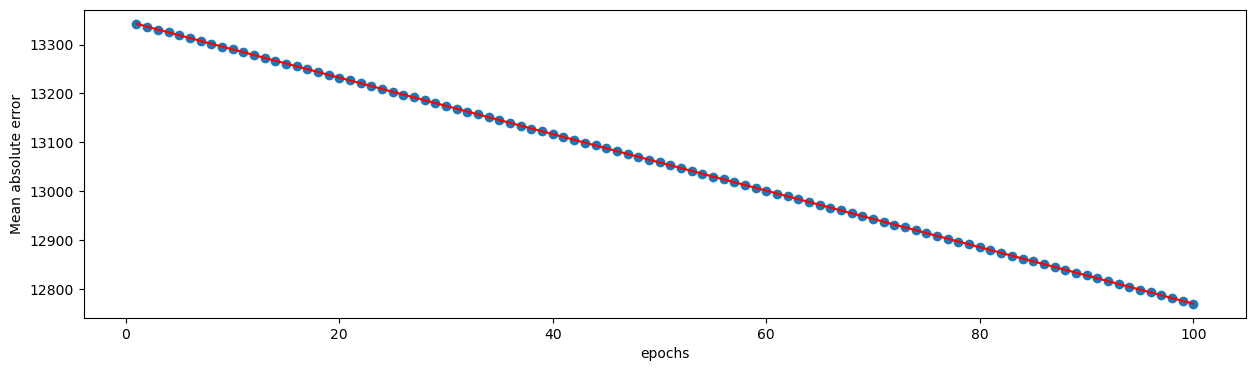

In [14]:
# see the error how it is reduced to minimum times for epoch
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.scatter(range(1,101),mae_values)
plt.plot(range(1,101),mae_values,color='red')
plt.ylabel("Mean absolute error")
plt.xlabel("epochs")
plt.show()